In [1]:
import cv2
import tensorflow as tf
from detect_face import detect_faces
import numpy as np

In [2]:
model = tf.keras.models.load_model('../models/base_model.keras')

In [3]:
def preprocess(face):
    face = cv2.resize(face, (224, 224))
    face = face / 255.0
    face = np.reshape(face, (1, 224, 224, 3))
    return face

In [4]:

def detect_face_from_frame(frame):
    import cv2
    path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

    face_cascade = cv2.CascadeClassifier(path)
    gray_scale_img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_scale_img, 1.1, 4)
    return faces


In [ ]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.convertScaleAbs(
        frame, alpha=1.2, beta=40
    )  # increase brightness..helpful when moved to dark area

    frame = cv2.GaussianBlur(frame, (5, 5), 0)

    faces = detect_face_from_frame(frame)

    for x, y, w, h in faces:
        face = frame[y : y + h, x : x + w]
        processed = preprocess(face)

        prediction = model.predict(processed)
        print("Prediction: \n", prediction)
        output = prediction[0][0]

        threshold = 0.6

        label = "Mask" if output < threshold else "No Mask"
        color = (0, 255, 0) if label == "Mask" else (0, 0, 255)

        cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
        cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    cv2.imshow("Mask Detection: ", frame)
    if cv2.waitKey(1) & 0xFF == 27:
        break
cap.release()
cv2.destroyAllWindows()

ret True
frame [[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]
ret True
frame [[[26 15 32]
  [32 24 39]
  [24 22 33]
  ...
  [ 0  0 16]
  [ 0  0 14]
  [ 0  0 14]]

 [[24 16 32]
  [31 24 40]
  [27 24 38]
  ...
  [ 0  0 17]
  [ 0  0 16]
  [ 0  0 16]]

 [[23 14 31]
  [22 16 32]
  [18 16 32]
  ...
  [ 0  0 17]
  [ 0  0 14]
  [ 0  0 14]]

 ...

 [[30 42 68]
  [25 42 69]
  [18 41 69]
  ...
  [ 6  0  9]
  [11  0  9]
  [11  0  9]]

 [[20 43 75]
  [14 39 71]
  [ 9 39 70]
  ...
  [ 0  0  9]
  [ 0  0  9]
  [ 0  0  9]]

 [[ 6 42 75]
  [ 3 40 73]
  [ 1 39 72]
  ...
  [ 0  0  9]
  [ 0  0  9]
  [ 0  0  9]]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/ste

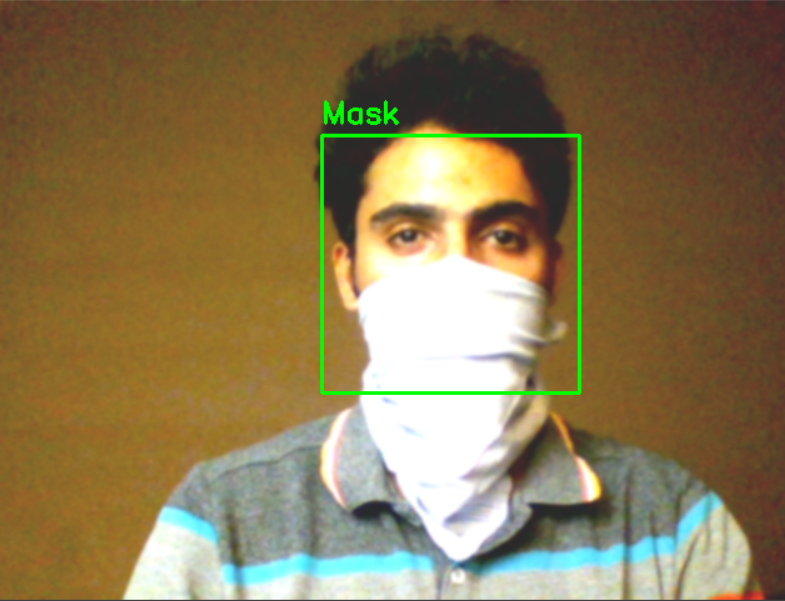

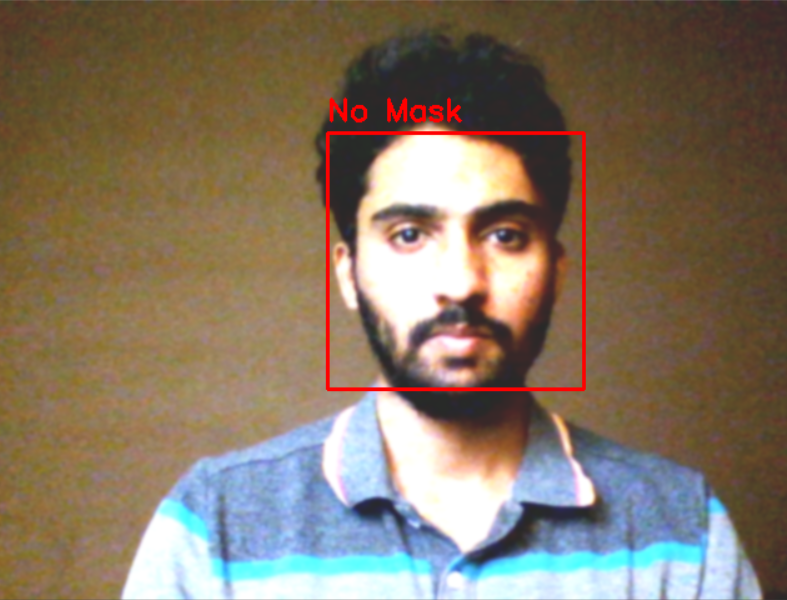